In [167]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [168]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [169]:
train_df = pd.read_csv("fashion-mnist_train.csv")
train_df.shape

(60000, 785)

In [170]:
test_df = pd.read_csv("fashion-mnist_test.csv")
test_df.shape

(10000, 785)

In [171]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [172]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [173]:
total_labels = train_df['label'].nunique()
total_labels

10

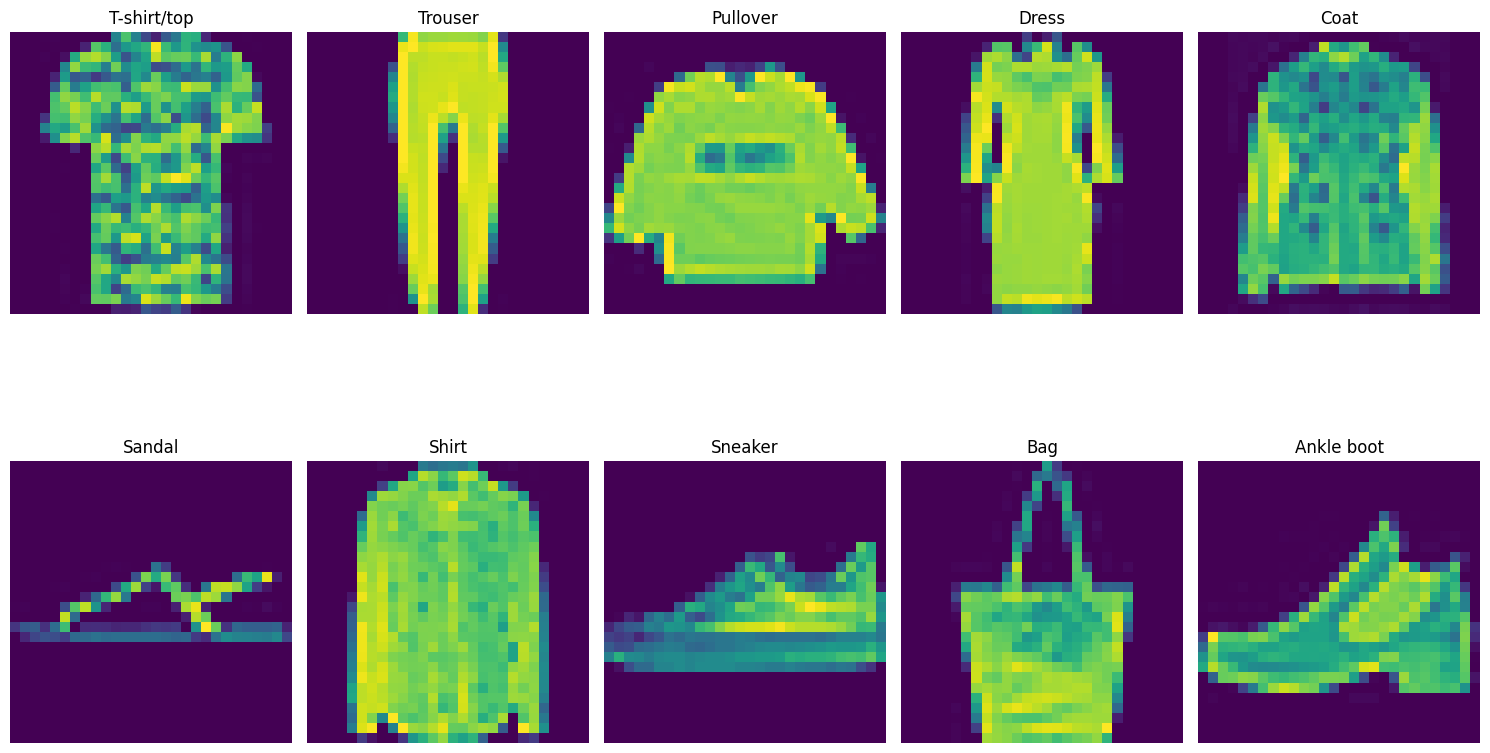

In [174]:
figure,axes = plt.subplots(2,5,figsize=(15,10))

for i in range(total_labels):
  filtered = train_df[train_df["label"] == i]
  pixels = filtered.iloc[0, 1:].values.reshape(28,28)
  axes[i//5,i%5].imshow(pixels)
  axes[i//5,i%5].set_title(class_names[i])
  axes[i//5,i%5].axis('off')

plt.tight_layout()
plt.show()

In [175]:
num_col = len(train_df.columns)
num_col

785

In [176]:
X_train = train_df.iloc[:,1:]
y_train = train_df.iloc[:,0]

In [152]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,0,0,0,0,0,0,0,0,0,1,...,69,12,0,0,0,0,0,0,0,0
5996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,0,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [177]:
X_test = test_df.iloc[:,1:]
y_test = test_df.iloc[:,0]

In [178]:
X_train.shape

(60000, 784)

In [179]:
y_train.shape

(60000,)

In [180]:
##normalization
X_train = X_train/255.0
X_test = X_test/255.0

## Custom Dataset

In [181]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features.to_numpy(),dtype=torch.float)
    self.labels = torch.tensor(labels.to_numpy(),dtype=torch.long)

  def __len__(self):
    return len(self.features)
  def __getitem__(self, index):
    return self.features[index],self.labels[index]

In [182]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [183]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [184]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features,256),
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)

    )
  def forward(self,features):
    return self.network(features)

In [185]:
model = MyNN(X_train.shape[1])
model.to(device)
model

MyNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [186]:
epochs = 15
learning_rate = 0.1
#loss function
criterion = nn.CrossEntropyLoss()
#optimizer
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [187]:
model.train()

epoch_loss = []
test_losses = []
test_accuracies = []
train_accuracies = []
for epoch in range(epochs):
  batch_loss = 0
  correct_train = 0
  for batch_features,batch_labels in train_loader:

    # move data to gpu
    batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)

    output = model(batch_features)
    loss = criterion(output,batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    batch_loss += loss.item()
    preds = torch.argmax(output,dim=1)
    correct_train += (preds==batch_labels).sum().item()
  train_acc_curr = correct_train/len(train_loader.dataset)
  train_accuracies.append(train_acc_curr)

  #valuation
  total_test_loss = 0
  correct_test = 0
  total_test = 0

  with torch.no_grad():
    for images,labels in test_loader:
      # move data to gpu
      images,labels = images.to(device), labels.to(device)

      y_pred = model(images)
      loss = criterion(y_pred,labels)
      total_test_loss += loss.item()
      preds = torch.argmax(y_pred,dim=1)
      correct_test += (preds==labels).sum().item()
      total_test += len(labels)
    test_loss = total_test_loss / len(test_loader)
    test_losses.append(test_loss)
    test_acc_curr = correct_test/total_test
    test_accuracies.append(test_acc_curr)

    avg_loss = batch_loss / len(train_loader)
    epoch_loss.append(avg_loss)
    print(f"Epoch {epoch+1}=Train Loss:{avg_loss:.4f} |Train Acc:{train_acc_curr*100:.4f}% |Test Loss:{test_loss:.4f} | Test Acc:{test_acc_curr*100:.4f}%")


Epoch 1=Train Loss:0.6678 |Train Acc:75.1167% |Test Loss:0.5196 | Test Acc:79.6000%
Epoch 2=Train Loss:0.4186 |Train Acc:84.6383% |Test Loss:0.3875 | Test Acc:85.4500%
Epoch 3=Train Loss:0.3721 |Train Acc:86.4100% |Test Loss:0.3649 | Test Acc:86.2700%
Epoch 4=Train Loss:0.3422 |Train Acc:87.3367% |Test Loss:0.3294 | Test Acc:87.8200%
Epoch 5=Train Loss:0.3242 |Train Acc:87.9417% |Test Loss:0.3331 | Test Acc:87.2800%
Epoch 6=Train Loss:0.3060 |Train Acc:88.6817% |Test Loss:0.3132 | Test Acc:88.3700%
Epoch 7=Train Loss:0.2903 |Train Acc:89.1867% |Test Loss:0.3244 | Test Acc:87.9800%
Epoch 8=Train Loss:0.2795 |Train Acc:89.4683% |Test Loss:0.3202 | Test Acc:88.0700%
Epoch 9=Train Loss:0.2685 |Train Acc:90.0350% |Test Loss:0.3093 | Test Acc:88.7600%
Epoch 10=Train Loss:0.2598 |Train Acc:90.2217% |Test Loss:0.3022 | Test Acc:88.4700%
Epoch 11=Train Loss:0.2517 |Train Acc:90.5167% |Test Loss:0.3075 | Test Acc:89.0100%
Epoch 12=Train Loss:0.2441 |Train Acc:90.7283% |Test Loss:0.2975 | Test Ac

In [188]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for features,labels in test_loader:
    features,labels = features.to(device), labels.to(device)
    outputs = model(features)
    preds = torch.argmax(outputs,dim=1)
    all_preds.append(preds)
    all_labels.append(labels)
  all_preds = torch.concat(all_preds)
  all_labels = torch.concat(all_labels)

  test_accuracy = (all_preds==all_labels).float().mean()*100
  print(f"Test Accuracy {test_accuracy:.2f}%")

Test Accuracy 88.94%


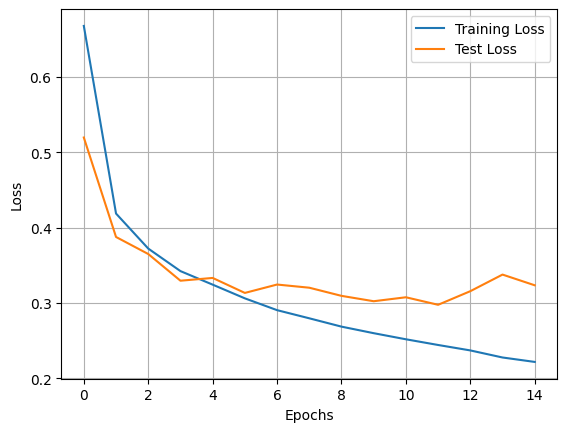

In [189]:
plt.plot(epoch_loss,label = "Training Loss")
plt.plot(test_losses,label = "Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()